# Text Classification with TF-IDF and Logistic Regression

## Introduction
This notebook demonstrates a classic NLP baseline: TF-IDF features paired with logistic regression. The project shows why simple linear text pipelines are still useful and how vectorizer settings act as a form of feature selection in sparse text problems.

## Project Goal
Classify two newsgroup categories, evaluate a strong text baseline, and compare a richer TF-IDF setup against a smaller and simpler one.

## Machine Learning Concepts Used
- Natural Language Processing
- Text Classification
- TF-IDF
- Sparse Features
- Logistic Regression
- Confusion Matrix
- Vocabulary Selection

## Dataset
`sklearn.datasets.fetch_20newsgroups`

## Step 1: Import libraries

**What this section is doing**  
Import the tools required for text loading, vectorization, model training, and evaluation.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

## Step 2: Load the text dataset

**What this section is doing**  
Use two categories from the 20 Newsgroups corpus to keep the classification task focused and interpretable.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [2]:
categories = ["sci.space", "rec.sport.baseball"]

raw = fetch_20newsgroups(
    subset="all",
    categories=categories,
    remove=("headers", "footers", "quotes")
)

texts = pd.Series(raw.data, name="text")
y = pd.Series(raw.target, name="target")

print("Sample count:", len(texts))
print("Target names:", raw.target_names)
display(texts.head())

Sample count: 1981
Target names: ['rec.sport.baseball', 'sci.space']


,text
0,\nDo you really have *that* much information o...
1,\n ^^^^^^\n\n\tSure they might. ...
2,------------------------- Original Article ---...
3,"\nNot really, though I wouldn't personally say..."
4,\nCan anybody name a player who was 'rushed' t...


## Step 3: Inspect example texts and class balance

**What this section is doing**  
Reading real examples keeps the problem concrete and helps connect the later vectorization step to actual language.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [3]:
print("Example text sample:")
print(texts.iloc[0][:1000])

print("\nClass proportions:")
display(y.value_counts(normalize=True))

Example text sample:

Do you really have *that* much information on him?  Really?


I don't know.  You tell me.  What percentage of players reach or 
exceed their MLE's *in their rookie season*?  We're talking about
1993, you know.


If that were your purpose, maybe.  Offerman spent 1992 getting 
acclimated, if you will.  The Dodgers as a team paid a big price
that season.  Perhaps they will reap the benefits down the road.
Do you really think they would have done what they did if they
were competing for a pennant?


For a stat-head, I'm amazed that you put any credence in spring
training.  Did you notice who he got those 10 (!) hits off of, or
are you going to tell me that it doesn't make a difference?


Wait a minute.  I missed something here.  First, forget Keith
Mitchell.  Are you saying that a kid who moves from AA to AAA
and then does not improve would have been better off making a
direct leap to the majors?  If a player does well at AA and then
does not improve at AAA, isn't tha

,proportion
target,
0,0.501767
1,0.498233


## Step 4: Split the dataset

**What this section is doing**  
Create a stratified split so the class proportions remain similar in the train and test sets.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    texts, y, test_size=0.2, random_state=42, stratify=y
)

## Step 5: Build TF-IDF features

**What this section is doing**  
TF-IDF transforms text into weighted numeric features. Including unigrams and bigrams allows the model to capture both individual words and short phrases.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [5]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Train matrix shape:", X_train_tfidf.shape)
print("Test matrix shape :", X_test_tfidf.shape)

Train matrix shape: (1584, 5000)
Test matrix shape : (397, 5000)


## Step 6: Train the logistic regression classifier

**What this section is doing**  
Linear models often work surprisingly well on sparse text representations, making logistic regression a strong NLP baseline.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [6]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

preds = model.predict(X_test_tfidf)

## Step 7: Evaluate the text classifier

**What this section is doing**  
Use a classification report and confusion matrix to inspect overall quality and the balance of the error types.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

                    precision    recall  f1-score   support

rec.sport.baseball       0.95      0.95      0.95       199
         sci.space       0.95      0.95      0.95       198

          accuracy                           0.95       397
         macro avg       0.95      0.95      0.95       397
      weighted avg       0.95      0.95      0.95       397



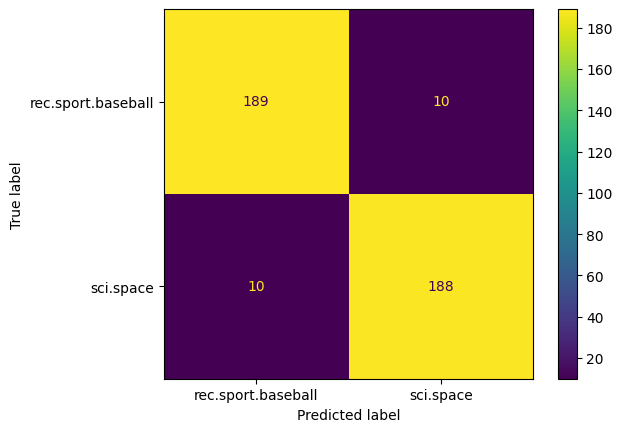

In [7]:
print(classification_report(y_test, preds, target_names=raw.target_names))

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=raw.target_names).plot()
plt.show()

## Step 8: Refine the text representation

**What this section is doing**  
Change the TF-IDF settings to a smaller unigram-only vocabulary and compare performance. In text problems, this acts like a form of feature selection.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

In [8]:
vectorizer_small = TfidfVectorizer(
    stop_words="english",
    max_features=1500,
    ngram_range=(1, 1)
)

X_train_small = vectorizer_small.fit_transform(X_train)
X_test_small = vectorizer_small.transform(X_test)

model_small = LogisticRegression(max_iter=1000, random_state=42)
model_small.fit(X_train_small, y_train)
preds_small = model_small.predict(X_test_small)

comparison_df = pd.DataFrame({
    "model": ["baseline_tfidf_bigram", "smaller_tfidf_unigram"],
    "f1_score": [
        f1_score(y_test, preds),
        f1_score(y_test, preds_small)
    ]
})

display(comparison_df)

,model,f1_score
0,baseline_tfidf_bigram,0.949495
1,smaller_tfidf_unigram,0.938144


## Step 9: Final analysis and next steps

**What this section is doing**  
Finish by explaining what TF-IDF captures well, where it falls short, and why the refinement experiment matters.

**Why this matters**  
This section exists so the workflow stays explicit, interpretable, and reproducible. In a professional notebook, each code cell should have a clear purpose before it is executed.

## Final Analysis and Next Steps

### Final Analysis
- **Overall Model Performance**: Both TF-IDF with Logistic Regression models performed very well in classifying the two newsgroup categories (`rec.sport.baseball` and `sci.space`). The `baseline_tfidf_bigram` model achieved an impressive F1-score of **0.949495**, and the `smaller_tfidf_unigram` model also performed strongly with an F1-score of **0.938144**.

- **Impact of N-grams and Vocabulary Size**:
  - The `baseline_tfidf_bigram` model, utilizing `ngram_range=(1, 2)` (unigrams and bigrams) and `max_features=5000`, shows a slight but noticeable improvement in F1-score compared to the `smaller_tfidf_unigram` model. This suggests that including bigrams, which capture phrases and word combinations, provides richer contextual information that helps the model differentiate between the two distinct topics more effectively.
  - The `smaller_tfidf_unigram` model, with a reduced `max_features=1500` and `ngram_range=(1, 1)` (unigrams only), still achieves a high F1-score. This demonstrates that even with a more constrained vocabulary and simpler features, TF-IDF is highly effective for this classification task. The minimal performance drop indicates that the most discriminative unigrams are potent enough to classify these categories with high accuracy, potentially offering advantages in computational efficiency if a slightly lower performance is acceptable.

- **Classification Report Details**:
  - For the `baseline_tfidf_bigram` model, the `classification_report` showed high precision, recall, and F1-scores (all 0.95) for both classes. This indicates that the model is very good at correctly identifying instances of each class (high precision) and also at finding most of the relevant instances for each class (high recall).
  - The `confusion_matrix` `[[189, 10], [10, 188]]` further illustrates this. Out of 199 `rec.sport.baseball` samples, 189 were correctly classified, and 10 were misclassified as `sci.space`. Similarly, out of 198 `sci.space` samples, 188 were correctly classified, and 10 were misclassified as `rec.sport.baseball`. This balanced error distribution across classes reinforces the F1-score and suggests no significant bias towards one category over the other.

- **TF-IDF as a Strong Baseline**: This experiment reconfirms TF-IDF as an excellent baseline for text classification. Its ability to quantify word importance, combined with the simplicity and effectiveness of Logistic Regression, yields strong results, especially for clearly separable categories like those chosen from the 20 Newsgroups dataset.

### Next Steps
- **Evaluate More Categories**: Expand the classification task to include more categories from the 20 Newsgroups dataset to test the model's generalization capabilities on a more complex multi-class problem.
- **Class Weighting for Imbalance**: If class imbalance becomes an issue with more categories, explore techniques like class weighting in the logistic regression model or over/under-sampling strategies to prevent the model from being biased towards majority classes.
- **Compare with Embedding-Based or Transformer-Based Methods**: For further improvement, investigate more advanced NLP techniques. This could involve using word embeddings (e.g., Word2Vec, GloVe) to capture semantic relationships between words, or leveraging transformer-based models (e.g., BERT, GPT) which can understand context and nuance more effectively than traditional TF-IDF.